# Do Bull Markets Die of Old Age? — a quantitative teardown 🔬
### Censored Weibull hazards · random-walk and GARCH nulls through the same dating rule · predictive regressions · a de-risk rule

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The comparison that
carries the study is **§4.3**: the Weibull shape of real bull markets judged not against k = 1 but
against the distribution of k for random-walk and GARCH(1,1)-t tapes with the same drift and
volatility, dated by the **same** ±20% rule. **§4.6** asks whether the real-time age of a bull
predicts the next 12 months, with Newey-West errors *and* a simulated null for the persistent
regressor; **§6** books the de-risking rule.

> **Beat 0 · Verdict (real tape).** Badges and prose numbers are sourced to
> [`docs/results.md`](../docs/results.md) (as-of 2022-11-30, FF fingerprint `394be76d78ac`,
> S&P fingerprint `e223c581ae22`, 1,000 paths per null). Cells below re-run the real tapes with 200
> null paths, so their p-values move in the second decimal.
>
> ⚠️ **Not investment advice.** The FF market series is **total return**; the S&P 500 tape is a
> **price index** (no dividends).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.0)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from oldage import data, strategy as st

In [2]:
ff = data.load_ff_monthly()                    # Fama-French market, TOTAL return, monthly
sp = data.load_sp500_daily()                   # S&P 500 PRICE index, daily (no dividends)
lv = data.total_return_index(ff["mkt"])
print(f"FF monthly total return {ff.index[0]:%Y-%m} → {ff.index[-1]:%Y-%m}  "
      f"fingerprint {data.fingerprint(ff)}")
print(f"S&P 500 daily price     {sp.index[0]:%Y-%m-%d} → {sp.index[-1]:%Y-%m-%d}  "
      f"fingerprint {data.fingerprint(sp)}")

FF monthly total return 1926-07 → 2018-11  fingerprint 394be76d78ac
S&P 500 daily price     1990-01-02 → 2022-11-30  fingerprint e223c581ae22


## Verdict, up front

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** | None | Real k = 1.10 (95% CI 0.72–2.00) vs random-walk median 1.22 (p = 0.72) and GARCH median 0.91 (p = 0.24); predictive slope NW t = -0.99, simulated p = 0.35; smallest p across four dating rules 0.24. |
| **Tradability** | Mirage | De-risk rule net Sharpe 0.489 vs 0.568 (Δ -0.079, CI -0.165 to +0.006); $1 → $773 vs $4,787; S&P daily Δ -0.087. |

> 💡 **In plain words.** Real bulls age exactly like bulls of a market with no memory, once
> both are measured with the same ruler — and selling old bulls just forfeits the equity premium.

## 1 · Hypotheses (fixed before the run)

- **H₁ (excess ageing).** The Weibull shape of real bull durations exceeds the 95th percentile of
  the shape produced by a random walk *and* by a GARCH(1,1)-t with the tape's drift, dated by the
  same rule. (`verdict`: Real iff the larger of the two one-sided p-values < 0.05.)
- **H₂ (prediction).** Real-time bull age has a negative slope for the next-12-month excess log
  return, NW t ≤ −2 and simulated p < 0.05 against both nulls.
- **H₃ (tradability).** Cutting equity to 50% in bulls older than the causal median improves the
  net excess-of-cash Sharpe (block-bootstrap p < 0.05; Fragile if p < 0.20), and the S&P daily tape
  agrees.
- **Null.** A raw k > 1, or a bootstrap CI excluding 1, earns **nothing** on its own.

## 2 · The dating rule

In [3]:
cy = st.date_cycles(lv, 0.20)
print(cy.assign(start=cy.start.dt.strftime("%Y-%m"), end=cy.end.dt.strftime("%Y-%m"),
                confirmed=cy.confirmed.dt.strftime("%Y-%m"))
        [["phase", "start", "end", "duration", "amplitude", "confirmed", "censored"]].to_string(index=False))
b = cy[cy.phase == "bull"]
lag = ((b.confirmed - b.end).dt.days / 30.44).dropna()
print(f"\nmedian months from the peak to its confirmation: {lag.median():.1f}")

phase   start     end  duration  amplitude confirmed  censored
 bear 1929-08 1932-06        34     -0.837   1932-07     False
 bull 1932-06 1932-08         2      0.835   1932-11     False
 bear 1932-08 1933-02         6     -0.289   1933-04     False
 bull 1933-02 1937-02        48      2.796   1937-09     False
 bear 1937-02 1938-03        13     -0.493   1938-06     False
 bull 1938-03 1940-04        25      0.649   1940-05     False
 bear 1940-04 1940-05         1     -0.220   1941-07     False
 bull 1940-05 1941-07        14      0.202   1942-04     False
 bear 1941-07 1942-04         9     -0.231   1942-10     False
 bull 1942-04 1946-05        49      2.289   1946-09     False
 bear 1946-05 1947-05        12     -0.242   1948-05     False
 bull 1947-05 1961-12       175      8.432   1962-06     False
 bear 1961-12 1962-06         6     -0.230   1963-01     False
 bull 1962-06 1968-11        77      1.602   1970-01     False
 bear 1968-11 1970-06        19     -0.336   1970-11   

> 💡 **In plain words.** A top is only known once prices are 20% below it — about half a
> year later, typically. That's why the trading rule in §6 has to use the *real-time* clock.

The S&P 500 daily price index, same rule — only a handful of cycles, so it serves as a cross-check:

In [4]:
spc = st.date_cycles(sp, 0.20)
print(spc.assign(months=(spc.duration / 21).round(1), start=spc.start.dt.date, end=spc.end.dt.date)
      [["phase", "start", "end", "months", "amplitude", "censored"]].to_string(index=False))

phase      start        end  months  amplitude  censored
 bull 1990-10-11 2000-03-24 113.700      4.170     False
 bear 2000-03-24 2001-09-21  17.800     -0.368     False
 bull 2001-09-21 2002-01-04   3.400      0.214     False
 bear 2002-01-04 2002-07-23   6.500     -0.320     False
 bull 2002-07-23 2007-10-09  62.500      0.962     False
 bear 2007-10-09 2008-11-20  13.500     -0.519     False
 bull 2008-11-20 2009-01-06   1.400      0.242     False
 bear 2009-01-06 2009-03-09   2.000     -0.276     False
 bull 2009-03-09 2020-02-19 131.200      4.005     False
 bear 2020-02-19 2020-03-23   1.100     -0.339     False
 bull 2020-03-23 2022-01-03  21.400      1.144     False
 bear 2022-01-03 2022-11-30  10.900     -0.149      True


## 3 · Why the null is the whole test

A ±20% filter needs a 20% rise to confirm a bull and a 20% fall from the high to end it, so a
young bull rarely ends: hazard starts low and rises. That is positive duration dependence
**manufactured by measurement**. Below, 300 memoryless random walks with the FF tape's monthly drift
and vol, dated by the same rule, each fitted with the same censored Weibull.

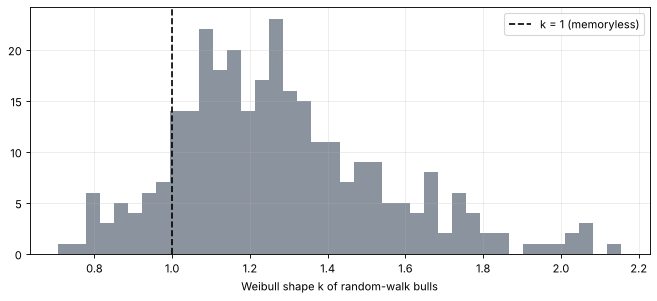

median k 1.25; share k>1 88%; naive LR test rejects k=1 (k>1) on 17% of memoryless paths


In [5]:
lr = np.log1p(ff["mkt"])
paths = st.simulate_log_returns("rw", len(lr), 300, {"mu": lr.mean(), "sigma": lr.std(ddof=1)}, seed=11)
ks, naive = [], []
for p in paths:
    d_, c_ = st._bulls_from_tps(st.turning_points(np.exp(np.cumsum(p)), 0.20), len(p))
    f_ = st.fit_weibull(d_, c_)
    if f_:
        ks.append(f_["k"]); naive.append(f_["k"] > 1 and f_["p_k1"] < 0.05)
ks = np.array(ks)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ks, bins=40, color="#8b949e")
ax.axvline(1, color="k", ls="--", label="k = 1 (memoryless)")
ax.set_xlabel("Weibull shape k of random-walk bulls"); ax.legend(); plt.show()
print(f"median k {np.median(ks):.2f}; share k>1 {np.mean(ks > 1):.0%}; naive LR test rejects k=1 (k>1) on {np.mean(naive):.0%} of memoryless paths")

> 💡 **In plain words.** Measure a coin-flip market with this ruler and it "dies of old age"
> most of the time. Testing real bulls against k = 1 would be testing the ruler.

## 4 · The teardown

### 4.1 · Censored Weibull on the real bulls

{'k': 1.104, 'lam': 84.248, 'loglik': -59.448, 'n': 12, 'n_events': 11, 'n_censored': 1, 'lr_k1': 0.15, 'p_k1': 0.699, 'median': 60.456}
cycle-bootstrap 95% CI for k: 0.72 – 1.95; share of draws with k>1: 74%


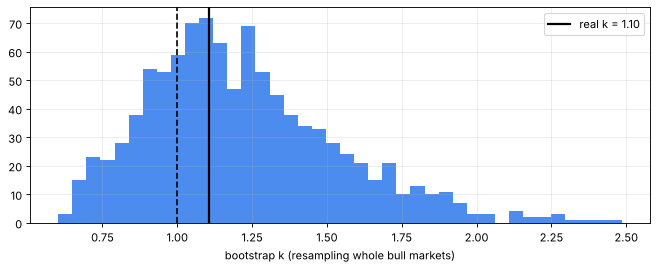

In [6]:
d, c = st.bull_durations(lv, 0.20)
fit = st.fit_weibull(d, c)
boot = st.weibull_bootstrap(d, c, n_boot=1000, seed=1017)
print({k: round(v, 3) if isinstance(v, float) else v for k, v in fit.items()})
print(f"cycle-bootstrap 95% CI for k: {boot['k_lo']:.2f} – {boot['k_hi']:.2f}; share of draws with k>1: {boot['share_k_gt_1']:.0%}")
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(boot["ks"], bins=40, color="#1f6feb", alpha=0.8)
ax.axvline(fit["k"], color="k", lw=2, label=f"real k = {fit['k']:.2f}")
ax.axvline(1, color="k", ls="--")
ax.set_xlabel("bootstrap k (resampling whole bull markets)"); ax.legend(); plt.show()

> 💡 **In plain words.** With eleven completed bulls the interval runs from "fragile when
> young" to "ages briskly". The data alone can't say much — which is exactly why the comparison has
> to be like-for-like.

### 4.2 · The life table

        at_risk  ended  censored  annual_hazard  random walk  GARCH
bucket                                                             
0–1y         12      1         0          0.083        0.161  0.251
1–2y         11      1         0          0.091        0.225  0.202
2–3y         10      2         0          0.200        0.221  0.128
3–5y          8      2         0          0.134        0.217  0.126
5–8y          6      2         0          0.126        0.226  0.111
8y+           4      3         1          0.154        0.224  0.127


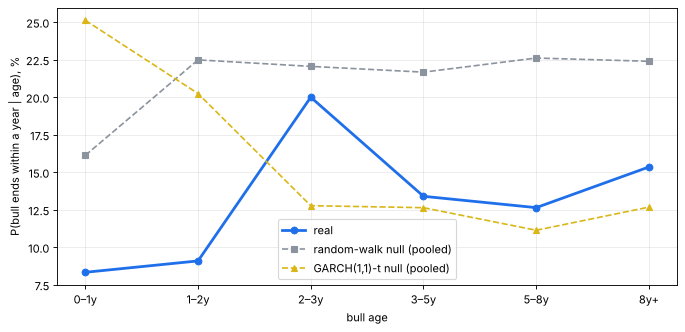

In [7]:
res = st.duration_test(ff["mkt"], 0.20, n_sims=200, n_boot=200, rf=ff["rf"], seed=1017)
lt = res["life"].copy()
lt["random walk"] = res["nulls"]["rw"]["life"]["annual_hazard"]
lt["GARCH"] = res["nulls"]["garch"]["life"]["annual_hazard"]
print(lt[["at_risk", "ended", "censored", "annual_hazard", "random walk", "GARCH"]].to_string())
x = np.arange(len(lt))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x, lt.annual_hazard * 100, "o-", lw=2.5, color="#1f6feb", label="real")
ax.plot(x, lt["random walk"] * 100, "s--", color="#8b949e", label="random-walk null (pooled)")
ax.plot(x, lt["GARCH"] * 100, "^--", color="#dab617", label="GARCH(1,1)-t null (pooled)")
ax.set_xticks(x); ax.set_xticklabels(lt.index); ax.set_ylabel("P(bull ends within a year | age), %")
ax.set_xlabel("bull age"); ax.legend(); plt.show()

The real hazard rises over the first three years and then flattens — below the random-walk curve
throughout (real bulls are *longer* than random-walk bulls) and close to the GARCH curve, whose
hazard *falls* with age because volatility clustering produces long calm bulls.

### 4.3 · The real k against both nulls

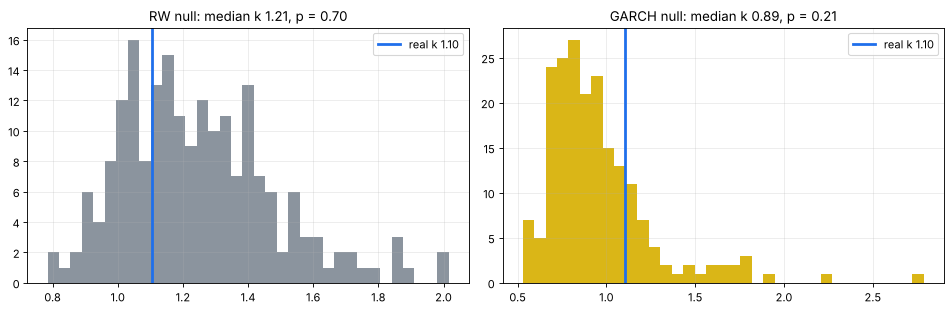

GARCH params (tape drift imposed): {'mu': 0.0079, 'omega': 0.0001, 'alpha': 0.13268, 'beta': 0.8306, 'nu': 6.61544}


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, kind, col in ((axes[0], "rw", "#8b949e"), (axes[1], "garch", "#dab617")):
    n = res["nulls"][kind]
    ax.hist(n["table"]["k"].dropna(), bins=35, color=col)
    ax.axvline(fit["k"], color="#1f6feb", lw=2.5, label=f"real k {fit['k']:.2f}")
    ax.set_title(f"{kind.upper()} null: median k {n['k_null_median']:.2f}, p = {n['p_k']:.2f}")
    ax.legend()
plt.tight_layout(); plt.show()
print("GARCH params (tape drift imposed):", {k: round(v, 5) for k, v in res["nulls"]["garch"]["params"].items()})

Pinned run (1,000 paths each): p = **0.72** vs the random walk, **0.24** vs
GARCH. H₁ fails against both.

> 💡 **In plain words.** Real bulls sit right in the middle of what memoryless markets
> produce. Nothing to explain.

### 4.4 · Sensitivity to the ruler

In [9]:
gp = res["nulls"]["garch"]["params"]
rows = []
for label, up, down in (("±15%", .15, .15), ("±25%", .25, .25), ("+20%/−15%", .20, .15)):
    r_ = st.duration_test(ff["mkt"], up, down, n_sims=150, n_boot=200, with_prediction=False,
                          garch_params=gp, seed=1017)
    rows.append({"rule": label, "bulls": r_["n_bulls"], "median_m": r_["median_bull"], "k": r_["fit"]["k"],
                 "k_rw": r_["nulls"]["rw"]["k_null_median"], "p_rw": r_["nulls"]["rw"]["p_k"],
                 "k_garch": r_["nulls"]["garch"]["k_null_median"], "p_garch": r_["nulls"]["garch"]["p_k"]})
print(pd.DataFrame(rows).to_string(index=False))

     rule  bulls  median_m     k  k_rw  p_rw  k_garch  p_garch
     ±15%     20    28.000 0.959 1.226 0.947    0.913    0.397
     ±25%      8    54.500 0.922 1.193 0.901    0.893    0.450
+20%/−15%     18    30.000 1.095 1.311 0.881    0.958    0.238


Across all four rules in the pinned run, the smallest p against either null is
0.24. The ±15% and ±25% rules give k *below* 1 on the real tape.

### 4.5 · Real-time age — no look-ahead

`realtime_state` runs the filter month by month; the age at *t* is months since the trough that
started the **confirmed** bull. Truncating the tape leaves every earlier state unchanged (unit-tested).

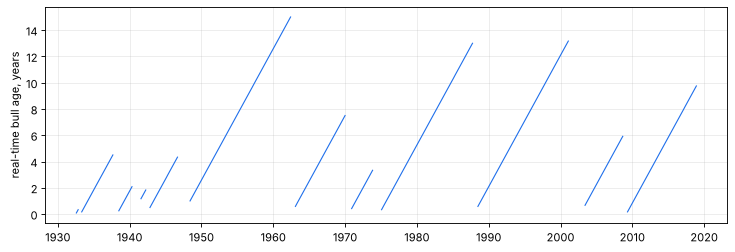

In [10]:
rt = st.realtime_state(lv, 0.20)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(rt.index, rt.age / 12, color="#1f6feb", lw=1)
ax.set_ylabel("real-time bull age, years"); plt.show()

### 4.6 · Does age predict the next 12 months?

                    target  slope/yr  NW t (18 lags)  non-overlap t   n  n non-overlap
next-12m excess log return    -0.004          -0.986         -0.954 898             75
     next-12m max drawdown    -0.002          -0.686         -0.055 898             75


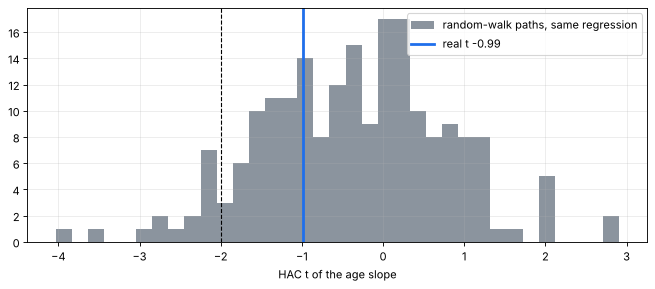

simulated p (RW) 0.33; share of null paths with t <= -2: 8%


In [11]:
pr = res["pred_raw"]
dd = st.predictive_regression(ff["mkt"], ff["rf"], target="drawdown")
print(pd.DataFrame([
    {"target": "next-12m excess log return", "slope/yr": pr["slope"], "NW t (18 lags)": pr["t"],
     "non-overlap t": pr["t_nonoverlap"], "n": pr["n"], "n non-overlap": pr["n_nonoverlap"]},
    {"target": "next-12m max drawdown", "slope/yr": dd["slope"], "NW t (18 lags)": dd["t"],
     "non-overlap t": dd["t_nonoverlap"], "n": dd["n"], "n non-overlap": dd["n_nonoverlap"]}]).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 3.8))
tn = res["nulls"]["rw"]["table"]["pred_t"].dropna()
ax.hist(tn, bins=35, color="#8b949e", label="random-walk paths, same regression")
ax.axvline(pr["t"], color="#1f6feb", lw=2.5, label=f"real t {pr['t']:+.2f}")
ax.axvline(-2, color="k", ls="--", lw=1)
ax.set_xlabel("HAC t of the age slope"); ax.legend(); plt.show()
print(f"simulated p (RW) {res['nulls']['rw']['p_pred']:.2f}; share of null paths with t <= -2: {(tn <= -2).mean():.0%}")

> 💡 **In plain words.** Age is a slowly-ticking clock, and regressions on slow clocks
> produce big-looking t-stats by accident — close to one random walk in ten gives t ≤ −2 here. The real
> t of -0.99 is unremarkable even before that correction.

Next-month excess return by real-time state — what a de-risker gives up:

In [12]:
W = st.age_rule_weights(lv, 0.20)
nxt = ff["mkt_rf"].shift(-1)
inb = W.age.notna() & W.median_age.notna()
old, young = inb & (W.age > W.median_age), inb & (W.age <= W.median_age)
rest = ~inb & W.median_age.notna()
rows = []
for name, m in (("young bull", young), ("old bull", old), ("bear / unconfirmed", rest)):
    x = nxt[m].dropna()
    rows.append({"state": name, "months": len(x), "mean (ann.)": x.mean() * 12,
                 "vol (ann.)": x.std() * np.sqrt(12), "Sharpe": x.mean() / x.std() * np.sqrt(12)})
print(pd.DataFrame(rows).to_string(index=False))

             state  months  mean (ann.)  vol (ann.)  Sharpe
        young bull     270        0.085       0.131   0.643
          old bull     559        0.093       0.139   0.669
bear / unconfirmed     113        0.026       0.200   0.132


Old bulls paid *at least* as well as young ones; the months the rule would sit fully invested
(bears, unconfirmed recoveries) paid the least. The timing is backwards before costs.

## 5 · The verdict

In [13]:
h = dict(n_years=len(ff) / 12, n_bulls=res["n_bulls"], k=fit["k"], k_lo=boot["k_lo"], k_hi=boot["k_hi"],
         k_null_rw=res["nulls"]["rw"]["k_null_median"], k_null_garch=res["nulls"]["garch"]["k_null_median"],
         p_k_rw=res["nulls"]["rw"]["p_k"], p_k_garch=res["nulls"]["garch"]["p_k"],
         p_pred_rw=res["nulls"]["rw"]["p_pred"], p_pred_garch=res["nulls"]["garch"]["p_pred"],
         pred_t=pr["t"], pred_slope=pr["slope"], cost_bps=10.0)
start = W.median_age.first_valid_index()
bt = st.age_rule_backtest(ff["mkt"], ff["rf"], W.weight, 10.0)
bt = bt[bt.index > start]
s = st.summarize_backtest(bt)
b = st.sharpe_diff_bootstrap(bt.net_x, bt.bh_x, n_boot=1000)
h.update(sharpe_bh=s["sharpe_bh"], sharpe_net=s["sharpe_net"], sharpe_diff=b["diff"], sharpe_lo=b["lo"],
         sharpe_hi=b["hi"], p_sharpe=b["p"], tw_bh=s["tw_bh"], tw_net=s["tw_net"],
         share_derisked=s["share_derisked"], sp_sharpe_diff=-0.087)   # S&P leg: see §6 / results.md
v = st.verdict(h)
print("Signal:", v["signal"], "| Tradability:", v["trad"])

Signal: None | Tradability: Mirage


Live re-run of `strategy.verdict` on this notebook's smaller simulation — it reproduces the pinned
stamps: **Signal None · Tradability Mirage**. The pinned rationale is in
[`docs/results.md`](../docs/results.md#verdict).

## 6 · Could you trade it?

 cost bp (one-way)  Sharpe B&H  Sharpe rule gross  Sharpe rule net  Δ net  CI lo  CI hi    $1 B&H  $1 rule net
             0.000       0.568              0.490            0.490 -0.077 -0.162  0.011 4,787.260      781.950
            10.000       0.568              0.490            0.489 -0.079 -0.163  0.009 4,787.260      773.357
            25.000       0.568              0.490            0.487 -0.081 -0.164  0.007 4,787.260      760.638

exposure-matched constant mix (70% equity, costless): Sharpe 0.568, $1 -> $1,079
de-risked 59% of months; one-way turnover 14% NAV/yr; vol 14.5% -> 11.2%; max DD -50% -> -46%


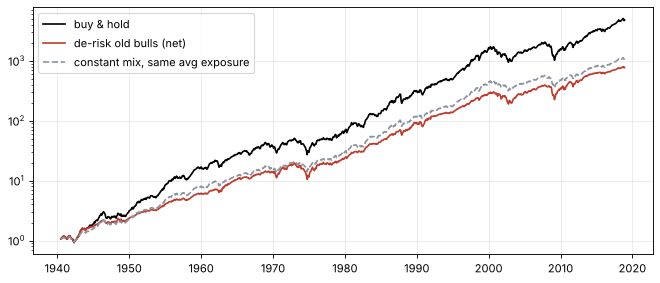

In [14]:
rows = []
for cbps in (0.0, 10.0, 25.0):
    bt_ = st.age_rule_backtest(ff["mkt"], ff["rf"], W.weight, cbps)
    bt_ = bt_[bt_.index > start]
    s_ = st.summarize_backtest(bt_)
    b_ = st.sharpe_diff_bootstrap(bt_.net_x, bt_.bh_x, n_boot=500)
    rows.append({"cost bp (one-way)": cbps, "Sharpe B&H": s_["sharpe_bh"], "Sharpe rule gross": s_["sharpe_gross"],
                 "Sharpe rule net": s_["sharpe_net"], "Δ net": b_["diff"], "CI lo": b_["lo"], "CI hi": b_["hi"],
                 "$1 B&H": s_["tw_bh"], "$1 rule net": s_["tw_net"]})
print(pd.DataFrame(rows).to_string(index=False))
cm = st.constant_mix(bt.bh, bt.rf, s["avg_weight"])
print(f"\nexposure-matched constant mix ({s['avg_weight']:.0%} equity, costless): Sharpe {st.sharpe(cm - bt.rf):.3f}, $1 -> ${(1 + cm).prod():,.0f}")
print(f"de-risked {s['share_derisked']:.0%} of months; one-way turnover {s['turnover_yr']:.0%} NAV/yr; "
      f"vol {s['vol_bh']:.1%} -> {s['vol_net']:.1%}; max DD {s['mdd_bh']:.0%} -> {s['mdd_net']:.0%}")
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy((1 + bt.bh).cumprod(), color="k", label="buy & hold")
ax.semilogy((1 + bt.net).cumprod(), color="#c0392b", label="de-risk old bulls (net)")
ax.semilogy((1 + cm).cumprod(), color="#8b949e", ls="--", label="constant mix, same avg exposure")
ax.legend(); plt.show()

> 💡 **In plain words.** The rule lowers risk the way any cash holding does, but it times
> it badly — it is worse than simply holding the same average amount of cash all the time
> ($1,079 vs $773 from $1). Costs barely matter: turnover is tiny. The loss
> is the timing.

Out-of-sample: daily S&P 500 **price** index 1990 → 2018-11, with the age threshold seeded by the
median of FF bulls confirmed before 1990 (cash = daily-ised T-bill). Pinned run: Sharpe gap
-0.087, rule worse. Capacity is not the issue — this is one index, monthly; the
rule fails on returns, not on size.

### Machinery proof (synthetic — not market evidence)

The same pipeline on `data.synthetic_monthly`: planted ageing (`signal_strength=1`) vs the exact
random-walk null (`0`).

In [15]:
rows = []
for s_ in (1.0, 0.0):
    dfs, tr = data.synthetic_monthly(n_months=len(ff), signal_strength=s_, seed=1017)
    rs = st.duration_test(dfs["mkt"], n_sims=100, n_boot=100, kinds=("rw",), rf=dfs["rf"])
    rows.append({"signal_strength": s_, "bulls": rs["n_bulls"], "k": rs["fit"]["k"],
                 "null k": rs["nulls"]["rw"]["k_null_median"], "p(k)": rs["nulls"]["rw"]["p_k"],
                 "pred t": rs["pred_raw"]["t"], "p(pred)": rs["nulls"]["rw"]["p_pred"]})
print(pd.DataFrame(rows).to_string(index=False))

 signal_strength  bulls     k  null k  p(k)  pred t  p(pred)
           1.000     20 2.544   1.191 0.010  -3.530    0.010
           0.000     13 1.374   1.163 0.178  -0.657    0.356


The harness flags planted ageing on both tests and stays quiet on the matched null — so the null
result on the real tape is about markets, not a blind detector.

## 7 · Going further

- **Power is the binding constraint.** Eleven completed bulls in 92 years. A fair summary is "no
  evidence of excess ageing", not "memorylessness proven"; a modest true effect would be invisible.
  International indices (pooled hazards across markets) are the obvious way to add cycles.
- **Valuation, not age.** The plausible channel for late-cycle fragility is time-varying expected
  returns. Replacing *age* with a valuation state in §4.6 is a different study.
- **Bry–Boschan / Pagan–Sossounov dating** with minimum phase and cycle lengths would remove the
  shortest phases on real *and* null tapes; it is the natural fork of `date_cycles`.
- **Duration-dependent Markov switching** (Maheu & McCurdy 2000) models the hazard inside a
  return-generating process instead of on dated cycles — a stronger but more model-dependent test.
- Challenge the nulls: add a slowly mean-reverting expected return to the random walk and see
  whether that alone produces real-looking ageing.